# Lab 1.4 — Named Entity Recognition: Press Releases  *(SOLUTION / instructor copy)*

**Course 1258 · Ch01 AI and ML Foundations** · 30 minutes (flex) · no API
key needed

**Objectives**
1. Explain what NER extracts and why it matters for government text.
2. Run two extractors (spaCy if present; rules+gazetteers always).
3. Render highlighted entities inline; chart counts by type and document.
4. Extend the extractor with a new rule and see it fire.

In [1]:
# Instructor copies live in solutions/, one level below labs/ — find labs/
# (where lab_common.py and data/ are) and run from there.
import os, sys
from pathlib import Path

for _cand in (Path.cwd(), Path.cwd().parent):
    if (_cand / "lab_common.py").is_file():
        os.chdir(_cand)
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

## Steps 1–2 — Data and the two-path extractor

**Instructor note.** The build VM has no spaCy, so transcripts show the
rule path. On a machine with spaCy the notebook switches automatically —
run both if you can and put the renderings side by side. Rule-path
expectations: 48 entities across the five releases (ORG 12, DATE 9,
PERSON 5, MONEY 5, EMAIL 5, PHONE 4, GPE 4, LAW 4). Per release: PR-001
8, PR-002 10, PR-003 9, PR-004 9, PR-005 12.

In [2]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

releases = json.load(open("data/press_releases.json"))["releases"]
pr = releases[0]
print(f"{len(releases)} releases loaded\n")
print(f"{pr['id']} — {pr['title']}\n({pr['agency']}, {pr['date']})\n")
print(pr["body"])

5 releases loaded

PR-001 — Chicago Pilots AI Assistant for 311 Service Requests
(City of Chicago Department of Transportation, April 6, 2026)

CHICAGO — The City of Chicago Department of Transportation announced on April 6, 2026 a 90-day pilot of an AI assistant that will help route 311 service requests to the correct bureau. Commissioner Maria Delgado said the assistant, developed with the Office of the Chief Data Officer at a cost of $1.2 million, will suggest a routing category for each request while a human dispatcher makes the final decision. The pilot covers Ward 28 and Ward 41 beginning June 1, 2026. "Every request will still be reviewed by a person," Delgado said. "The tool drafts, the dispatcher decides." Media inquiries: press@cityofchicago.example.gov or 312-555-0148.


In [3]:
try:
    import spacy
    _nlp = spacy.load("en_core_web_sm")
    HAVE_SPACY = True
except Exception:
    _nlp = None
    HAVE_SPACY = False

_SPACY_LABELS = {"ORG", "PERSON", "GPE", "DATE", "MONEY", "LAW"}

MONTHS = ("January|February|March|April|May|June|July|August|September|"
          "October|November|December")
REGEXES = [
    ("DATE",  rf"\b(?:{MONTHS}) \d{{1,2}}, \d{{4}}\b"),
    ("MONEY", r"\$\d+(?:\.\d+)? (?:million|billion)"),
    ("EMAIL", r"[\w.+-]+@[\w-]+\.[\w.-]+"),
    ("PHONE", r"\b\d{3}-\d{3}-\d{4}\b"),
]

GAZETTEERS = {
    "ORG": ["City of Chicago Department of Transportation",
            "Office of the Chief Data Officer",
            "U.S. Environmental Protection Agency", "EPA Region 9", "EPA",
            "U.S. General Services Administration",
            "Technology Transformation Service",
            "Centers for Disease Control and Prevention", "CDC",
            "National Wastewater Surveillance System",
            "U.S. Department of Veterans Affairs",
            "Office of Information and Technology",
            "Records Management Center"],
    "PERSON": ["Maria Delgado", "David Chen", "Robin Patel",
               "Dr. Elena Brooks", "Elena Brooks", "Thomas Reyes"],
    "GPE": ["San Bernardino County", "California", "San Francisco",
            "Chicago", "Washington", "Atlanta", "St. Louis", "Missouri"],
    "LAW": ["Clean Air Act", "Federal Acquisition Regulation",
            "Section 508", "Federal Records Act"],
}


def _rule_entities(text):
    spans = []
    for label, pattern in REGEXES:
        for m in re.finditer(pattern, text):
            spans.append({"start": m.start(), "end": m.end(),
                          "label": label, "text": m.group()})
    for label, names in GAZETTEERS.items():
        for name in names:
            for m in re.finditer(re.escape(name), text):
                spans.append({"start": m.start(), "end": m.end(),
                              "label": label, "text": m.group()})
    spans.sort(key=lambda e: (e["start"], -(e["end"] - e["start"])))
    kept, last_end = [], -1
    for e in spans:
        if e["start"] >= last_end:
            kept.append(e)
            last_end = e["end"]
    return kept


def extract_entities(text):
    if HAVE_SPACY:
        return [{"start": e.start_char, "end": e.end_char,
                 "label": e.label_, "text": e.text}
                for e in _nlp(text).ents if e.label_ in _SPACY_LABELS]
    return _rule_entities(text)


print(f"extractor ready — path: "
      f"{'spaCy (en_core_web_sm)' if HAVE_SPACY else 'rules + gazetteers (spaCy not installed)'}")

extractor ready — path: rules + gazetteers (spaCy not installed)


## Step 3 — Highlighted rendering

**What to point at (rule path, PR-001):** 8 entities — and zero GPE.
Two teaching gold nuggets: (1) the dateline "CHICAGO —" is ALL-CAPS, so
the case-sensitive gazetteer misses it; (2) the other "Chicago" is
swallowed inside the longer ORG span "City of Chicago Department of
Transportation" by the overlap resolver. Both are *design decisions*,
not bugs — and both are exactly the kind of thing a reviewer must know.

In [4]:
from html import escape
from IPython.display import HTML, display

LABEL_COLORS = {
    "ORG": "#aee1f9", "PERSON": "#f9c6d0", "GPE": "#c9f0c2",
    "DATE": "#f9e3a8", "MONEY": "#d9ccf9", "LAW": "#f5cda8",
    "EMAIL": "#e2e2e2", "PHONE": "#e2e2e2", "WARD": "#b8e6d4",
}


def render_entities(text, ents, title=None):
    ents = sorted(ents, key=lambda e: e["start"])
    parts, pos = [], 0
    for e in ents:
        parts.append(escape(text[pos:e["start"]]))
        color = LABEL_COLORS.get(e["label"], "#dddddd")
        parts.append(
            f'<mark style="background:{color};padding:2px 5px;'
            f'border-radius:4px">{escape(e["text"])}'
            f'<small style="font-weight:bold;color:#555">'
            f' {e["label"]}</small></mark>')
        pos = e["end"]
    parts.append(escape(text[pos:]))
    head = (f"<div style='font-weight:bold;margin-top:12px'>{escape(title)}"
            f"</div>") if title else ""
    return HTML(head + "<p style='font-family:Georgia,serif;"
                "line-height:2.0'>" + "".join(parts) + "</p>")


for r in releases[:3]:
    ents = extract_entities(r["body"])
    display(render_entities(r["body"], ents, title=f"{r['id']} — {r['title']}"))

## Steps 4–5 — Charts

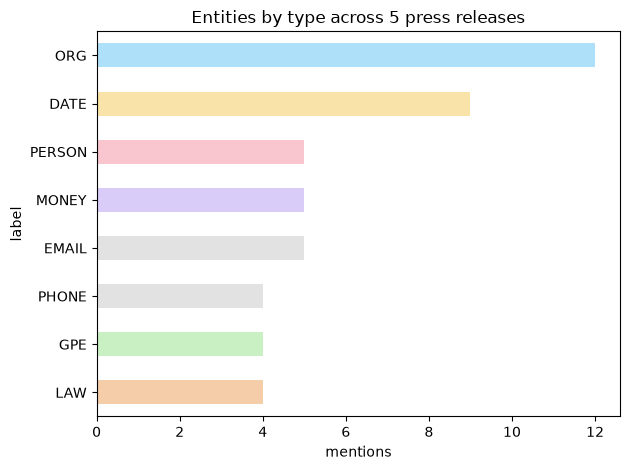

label
ORG       12
DATE       9
PERSON     5
MONEY      5
EMAIL      5
PHONE      4
GPE        4
LAW        4


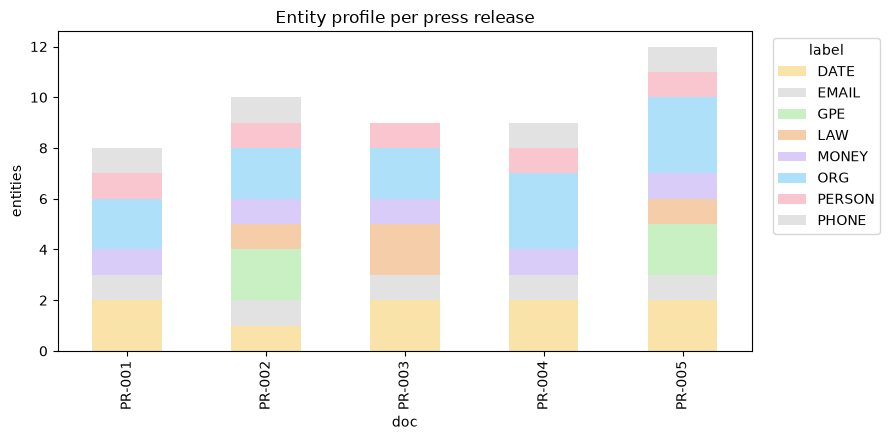

In [5]:
all_ents = []
for r in releases:
    for e in extract_entities(r["body"]):
        all_ents.append({"doc": r["id"], **e})
ent_df = pd.DataFrame(all_ents)

by_label = ent_df["label"].value_counts()
by_label.plot.barh(
    color=[LABEL_COLORS.get(l, "#bbb") for l in by_label.index],
    title=f"Entities by type across {len(releases)} press releases",
    xlabel="mentions")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(by_label.to_string())

per_doc = (ent_df.groupby(["doc", "label"]).size()
           .unstack(fill_value=0)
           .reindex(sorted(ent_df["doc"].unique())))
per_doc.plot.bar(stacked=True, figsize=(9, 4.5),
                 color=[LABEL_COLORS.get(c, "#bbb") for c in per_doc.columns],
                 ylabel="entities", title="Entity profile per press release")
plt.legend(title="label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## Step 6 — worked: add the WARD rule

**Expected:** PR-001 goes from 8 to 10 entities ("Ward 28" and
"Ward 41" light up). Accept any working rule — a gazetteer addition or
another regex. The grading point is that students *test* the rule
(before/after counts), not just write it.

In [6]:
before = len(extract_entities(releases[0]["body"]))

REGEXES.append(("WARD", r"\bWard \d+\b"))

after = len(extract_entities(releases[0]["body"]))
print(f"entities in PR-001: before={before}, after={after}")
display(render_entities(releases[0]["body"],
                        extract_entities(releases[0]["body"]),
                        title="PR-001 — after the WARD rule"))

entities in PR-001: before=8, after=10


## Step 7 — worked: the memo stretch

**Expected (rule path):** only 2 entities — "Office of the Chief Data
Officer" and "March 14, 2026". The gazetteer knows almost nothing about
the memo: it misses "Social Security numbers", "one business day", the
Department itself. This is the strongest argument in the lab for why
extractors get *tuned per corpus* — and why a statistical model earns
its keep on unseen text.

In [7]:
memo = open("data/gov_memo.txt").read()
memo_ents = extract_entities(memo)
print(f"{len(memo_ents)} entities found in gov_memo.txt")
display(render_entities(memo, memo_ents, title="gov_memo.txt"))

2 entities found in gov_memo.txt


## Grading notes

- **Mistag/missed note:** any one concrete observation earns full marks
  (the ALL-CAPS dateline, a swallowed GPE, a spaCy oddity).
- **Added rule:** must show before/after counts. A rule that changes
  nothing earns half — and a conversation about how they tested it.
- **Deploy question (Deliverable 4):** look for "gazetteer where the
  list is stable and auditable (redaction, compliance); statistical
  model where text is open-ended and recall matters (search, triage)".
- **Reflection 1:** redaction favors high-recall rules + human review;
  indexing favors recall of the model with tolerance for noise. Either
  direction is fine when defended with the cost of a miss vs the cost
  of a false alarm.